In [15]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Union
import pandas as pd


def plot_generation_lengths(
    pkl_path: Union[str, Path], 
    output_path: Union[str, Path] = None,
    figsize: tuple = (12, 8),
    style: str = "whitegrid",
    palette: str = "viridis"
) -> None:
    """
    Create a beautiful plot showing generation lengths vs scale values with uncertainty bands.
    
    Args:
        pkl_path: Path to the GenerationCollector pickle file
        output_path: Where to save the plot (optional)
        figsize: Figure size as (width, height)
        style: Seaborn style for the plot
        palette: Color palette for the visualization
    """
    
    # Load the GenerationCollector data
    pkl_path = Path(pkl_path)
    with pkl_path.open("rb") as f:
        data = pickle.load(f)
    
    print(data.keys())

    scale_key = "knob_values" if "knob_values" in data else "scale_values"
    
    scale_values = data[scale_key]
    lengths = data["lengths"]

    # Convert to DataFrame for easier manipulation
    df = pd.DataFrame({
        'scale_value': scale_values,
        'length': lengths
    })
    
    # Group by scale value and compute statistics
    stats = df.groupby('scale_value')['length'].agg([
        'mean', 'std', 'count', 'min', 'max'
    ]).reset_index()

    
    # Set up the plotting style
    plt.style.use('default')
    sns.set_style(style)
    
    # Create figure and axis
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create color palette
    colors = sns.color_palette(palette, n_colors=3)
    primary_color = colors[0]
    secondary_color = colors[1]
    accent_color = colors[2]
    
    # Plot the mean line with enhanced styling
    ax.plot(
        stats['scale_value'], 
        stats['mean'], 
        color=primary_color,
        linewidth=3,
        marker='o',
        markersize=8,
        markerfacecolor='white',
        markeredgecolor=primary_color,
        markeredgewidth=2,
        label='Mean Length',
        zorder=3
    )
    
    # Add uncertainty bands (mean ± std)
    ax.fill_between(
        stats['scale_value'],
        stats['mean'] - stats['std'],
        stats['mean'] + stats['std'],
        alpha=0.3,
        color=primary_color,
        label='±1 Standard Deviation',
        zorder=1
    )
    
    # Add a lighter band for ±2 std if data exists
    valid_2std = ~(pd.isna(stats['std']) | (stats['std'] == 0))
    if valid_2std.any():
        ax.fill_between(
            stats['scale_value'][valid_2std],
            (stats['mean'] - 2*stats['std'])[valid_2std],
            (stats['mean'] + 2*stats['std'])[valid_2std],
            alpha=0.15,
            color=primary_color,
            label='±2 Standard Deviations',
            zorder=0
        )
    
    # Add scatter points for individual measurements with jitter
    jitter_strength = 0.02
    jittered_scales = df['scale_value'] + np.random.normal(0, jitter_strength, len(df))
    
    ax.scatter(
        jittered_scales,
        df['length'],
        alpha=0.4,
        s=25,
        color=secondary_color,
        edgecolors='white',
        linewidth=0.5,
        label='Individual Generations',
        zorder=2
    )
    
    # Enhance the plot aesthetics
    ax.set_xlabel('Scale Value', fontsize=14, fontweight='bold')
    ax.set_ylabel('Generation Length (tokens)', fontsize=14, fontweight='bold')
    ax.set_title(
        'Stochastic Generation Length vs Vector Injection Scale\n'
        'Effect of Scale Parameter on Text Generation Variability',
        fontsize=16,
        fontweight='bold',
        pad=20
    )
    
    # Grid styling
    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.8)
    ax.set_axisbelow(True)
    
    # Legend styling
    legend = ax.legend(
        loc='upper left',
        frameon=True,
        fancybox=True,
        shadow=True,
        fontsize=11,
        title='Components',
        title_fontsize=12
    )
    legend.get_frame().set_facecolor('white')
    legend.get_frame().set_alpha(0.9)
    
    # Add summary statistics text box
    n_total = len(df)
    n_unique_scales = len(stats)
    mean_reps = stats['count'].mean()
    
    textstr = '\n'.join([
        f'Total Generations: {n_total:,}',
        f'Unique Scale Values: {n_unique_scales}',
        f'Avg Reps per Scale: {mean_reps:.1f}',
        f'Length Range: {df["length"].min()}-{df["length"].max()} tokens'
    ])
    
    props = dict(boxstyle='round,pad=0.5', facecolor=accent_color, alpha=0.1)
    ax.text(
        0.98, 0.02, textstr,
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment='bottom',
        horizontalalignment='right',
        bbox=props
    )
    
    # Enhance axis styling
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)
    
    # Adjust layout
    plt.tight_layout()
    
    # Save if output path provided
    if output_path:
        output_path = Path(output_path)
        plt.savefig(
            output_path,
            dpi=300,
            bbox_inches='tight',
            facecolor='white',
            edgecolor='none'
        )
        print(f"Plot saved to: {output_path}")
    
    # Show the plot
    plt.show()
    
    # Print summary statistics
    print("\n" + "="*60)
    print("GENERATION LENGTH ANALYSIS SUMMARY")
    print("="*60)
    print(f"Scale Value Range: {stats['scale_value'].min():.3f} to {stats['scale_value'].max():.3f}")
    print(f"Length Statistics:")
    print(f"  Overall Mean: {df['length'].mean():.1f} ± {df['length'].std():.1f} tokens")
    print(f"  Overall Range: {df['length'].min()} - {df['length'].max()} tokens")
    print(f"  Median Length: {df['length'].median():.1f} tokens")
    
    # Show scale-dependent trends
    print(f"\nScale-dependent trends:")
    scale_length_corr = np.corrcoef(df['scale_value'], df['length'])[0, 1]
    print(f"  Correlation (scale vs length): {scale_length_corr:.3f}")
    
    # Find most/least variable scales
    most_variable_idx = stats['std'].idxmax()
    least_variable_idx = stats['std'].idxmin()
    
    print(f"  Most variable scale: {stats.loc[most_variable_idx, 'scale_value']:.3f} "
          f"(std: {stats.loc[most_variable_idx, 'std']:.1f})")
    print(f"  Least variable scale: {stats.loc[least_variable_idx, 'scale_value']:.3f} "
          f"(std: {stats.loc[least_variable_idx, 'std']:.1f})")


def compare_multiple_experiments(
    pkl_paths: list[Union[str, Path]], 
    labels: list[str] = None,
    output_path: Union[str, Path] = None,
    figsize: tuple = (14, 10)
) -> None:
    """
    Compare generation length patterns across multiple experiments.
    
    Args:
        pkl_paths: List of paths to GenerationCollector pickle files
        labels: Optional labels for each experiment
        output_path: Where to save the comparison plot
        figsize: Figure size as (width, height)
    """
    
    if labels is None:
        labels = [f"Experiment {i+1}" for i in range(len(pkl_paths))]
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=figsize)
    colors = sns.color_palette("husl", n_colors=len(pkl_paths))
    
    for i, (pkl_path, label, color) in enumerate(zip(pkl_paths, labels, colors)):
        # Load data
        with Path(pkl_path).open("rb") as f:
            data = pickle.load(f)
        
        print(data.keys())
        
        scale_key = "knob_values" if "knob_values" in data else "scale_values"
        
        df = pd.DataFrame({
            'scale_value': data[scale_key],
            'length': data["lengths"]
        })
        
        stats = df.groupby('scale_value')['length'].agg(['mean', 'std']).reset_index()
        
        # Plot mean with uncertainty
        ax1.plot(
            stats['scale_value'], 
            stats['mean'], 
            color=color,
            linewidth=2.5,
            marker='o',
            markersize=6,
            label=label,
            alpha=0.8
        )
        
        ax1.fill_between(
            stats['scale_value'],
            stats['mean'] - stats['std'],
            stats['mean'] + stats['std'],
            alpha=0.2,
            color=color
        )
        
        # Distribution comparison
        ax2.hist(
            df['length'],
            bins=30,
            alpha=0.6,
            color=color,
            label=label,
            density=True
        )
    
    # Styling
    ax1.set_xlabel('Scale Value', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Mean Generation Length', fontsize=12, fontweight='bold')
    ax1.set_title('Comparison of Scale Effects Across Experiments', fontsize=14, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    ax2.set_xlabel('Generation Length (tokens)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Density', fontsize=12, fontweight='bold')
    ax2.set_title('Length Distribution Comparison', fontsize=14, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if output_path:
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        print(f"Comparison plot saved to: {output_path}")
    
    plt.show()




dict_keys(['scale_values', 'outputs', 'lengths'])


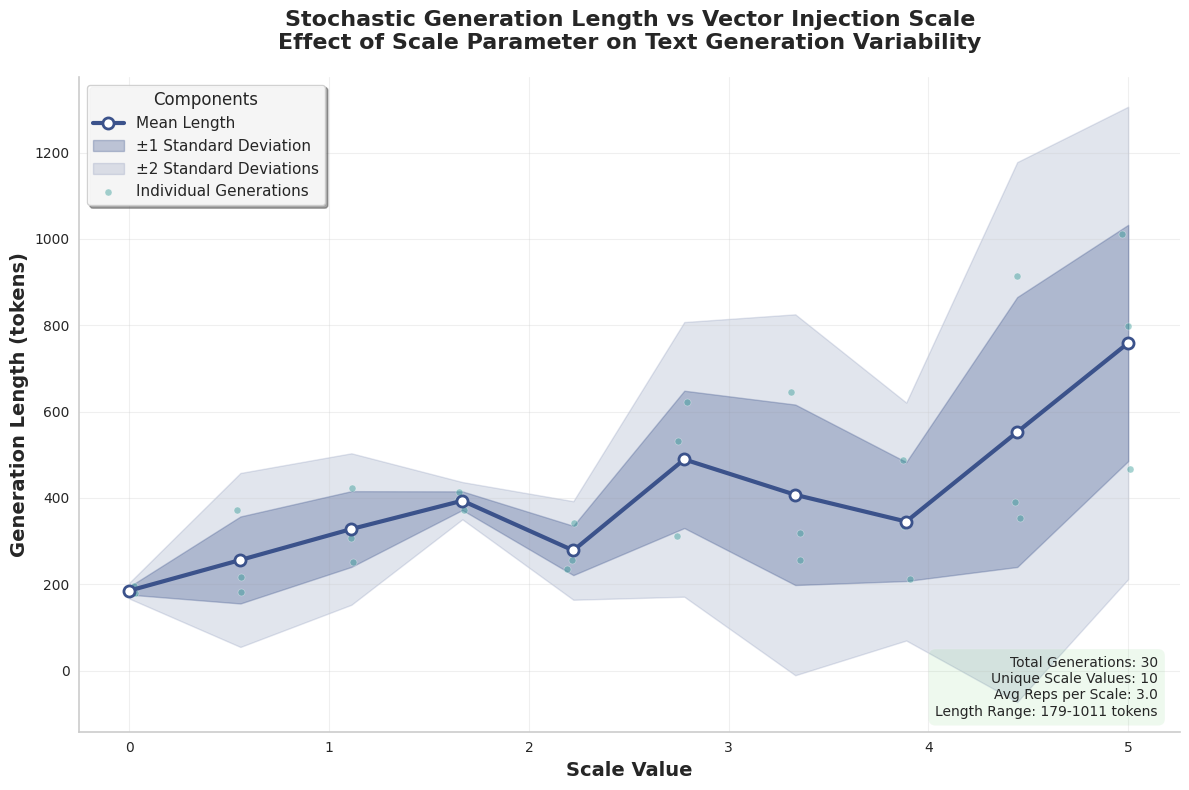


GENERATION LENGTH ANALYSIS SUMMARY
Scale Value Range: 0.000 to 5.000
Length Statistics:
  Overall Mean: 399.5 ± 212.9 tokens
  Overall Range: 179 - 1011 tokens
  Median Length: 348.5 tokens

Scale-dependent trends:
  Correlation (scale vs length): 0.630
  Most variable scale: 4.444 (std: 312.6)
  Least variable scale: 0.000 (std: 9.3)


In [16]:
plot_generation_lengths(
    pkl_path="/workspace/reasoning_vector_research/vector_injection_and_generation_experiment/reason_prompt_0_bos_vector_sweep_20250804.pkl",    output_path= None,
    figsize=(12, 8),
    style="whitegrid",
    palette="viridis"
)

dict_keys(['scale_values', 'outputs', 'lengths'])


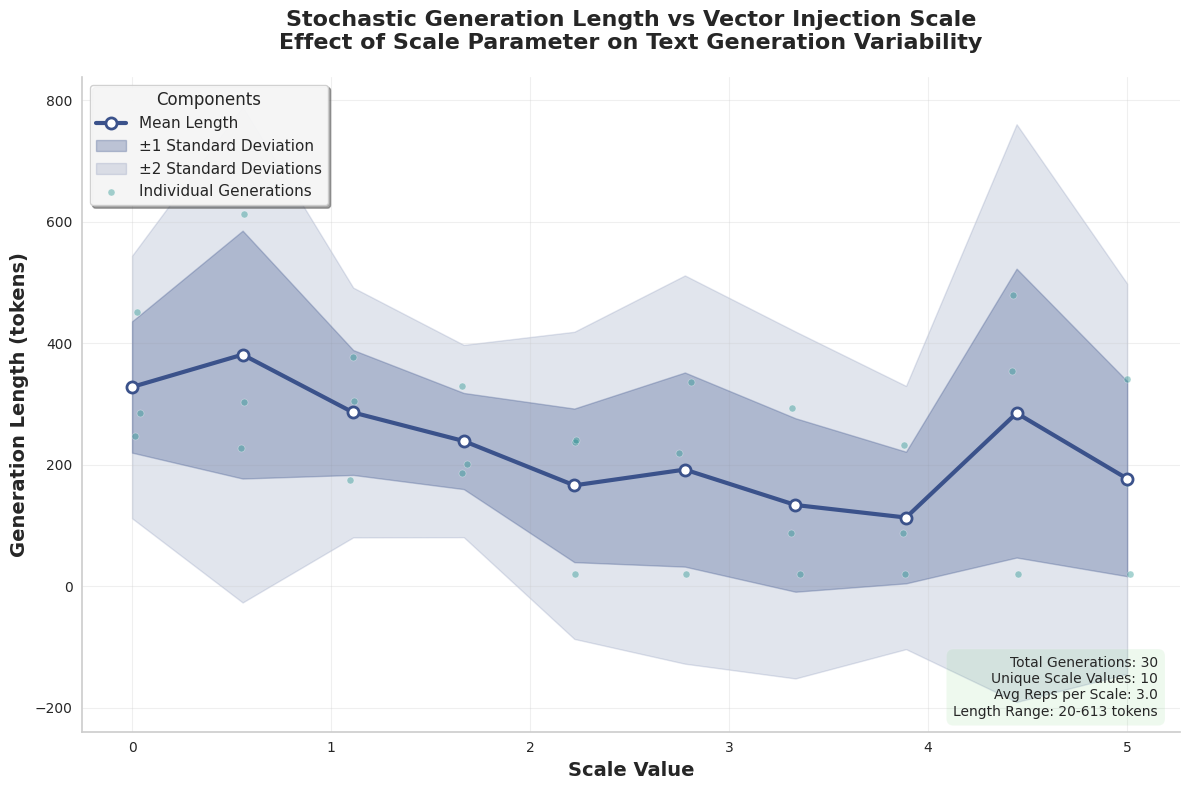


GENERATION LENGTH ANALYSIS SUMMARY
Scale Value Range: 0.000 to 5.000
Length Statistics:
  Overall Mean: 230.1 ± 151.2 tokens
  Overall Range: 20 - 613 tokens
  Median Length: 234.5 tokens

Scale-dependent trends:
  Correlation (scale vs length): -0.373
  Most variable scale: 4.444 (std: 237.9)
  Least variable scale: 1.667 (std: 79.2)


In [17]:
plot_generation_lengths(
    pkl_path="/workspace/reasoning_vector_research/vector_injection_and_generation_experiment/reason_prompt_0_nn_vector_sweep_20250804.pkl",    output_path= None,
    figsize=(12, 8),
    style="whitegrid",
    palette="viridis"
)

dict_keys(['knob_values', 'outputs', 'lengths'])


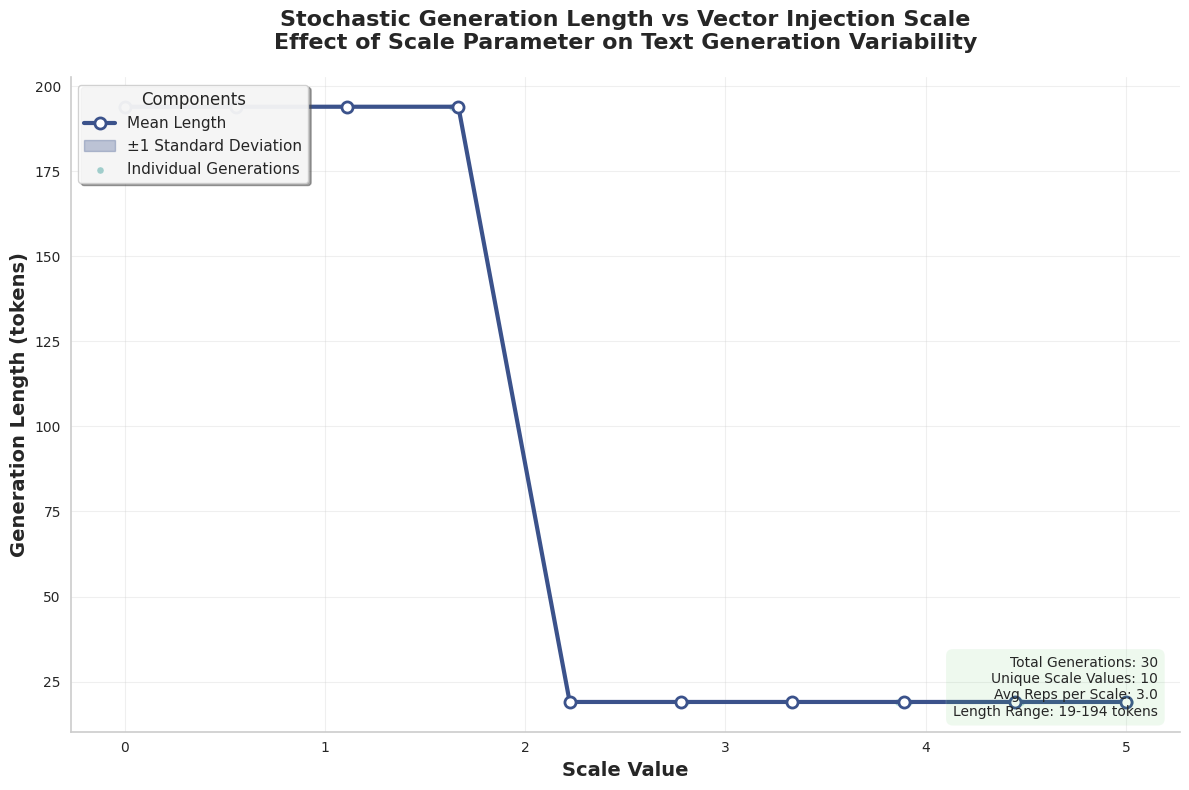


GENERATION LENGTH ANALYSIS SUMMARY
Scale Value Range: 0.000 to 5.000
Length Statistics:
  Overall Mean: 89.0 ± 87.2 tokens
  Overall Range: 19 - 194 tokens
  Median Length: 19.0 tokens

Scale-dependent trends:
  Correlation (scale vs length): -0.853
  Most variable scale: 0.000 (std: 0.0)
  Least variable scale: 0.000 (std: 0.0)


In [18]:
plot_generation_lengths(
    pkl_path="reason_prompt_answer_vector_sweep_20250804.pkl", 
    output_path= None,
    figsize=(12, 8),
    style="whitegrid",
    palette="viridis"
)

In [ ]:
plot_generation_lengths(
    pkl_path="reason_prompt_reason_vector_sweep_20250804.pkl",
    output_path= None,
    figsize=(12, 8),
    style="whitegrid",
    palette="viridis"
)

In [4]:
# Core libraries
import json
import numpy as np
import pickle
import torch
from pathlib import Path
from typing import Any, Dict, Union

# ML/Analysis libraries
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

# Project-specific imports
from tl_tools import *
from residual_stream_collection_tools import format_prompt


/workspace/reasoning_vector_research/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
model = load_llama8br1() 



Loading checkpoint shards: 100%|██████████| 2/2 [00:03<00:00,  1.50s/it]


Loaded model and tokenizer from local cache.
Loaded pretrained model meta-llama/Llama-3.1-8B into HookedTransformer


In [6]:
from run_vector_sweep_reasoning_len_experiment import *


In [7]:
output_file = "./tmp/test.pkl"
prompt = "What is the fifth prime?"
format_type = "reason"




collector = GenerationCollector(filepath=output_file)
formatted_prompt = format_prompt(model, prompt, format_type)

In [8]:
model.cfg.d_model

4096

In [9]:
ov_outs = analyze_ov_outputs(
    prompts=[format_prompt(model, prompt, 'immediate_answer')],
    layer_idx=2,
    head=(2, 17),
    indices=[-1],
    model=model
)


captured shape torch.Size([1, 13, 4096])


In [10]:
model.to_str_tokens(format_prompt(model, prompt, 'immediate_answer'))

['<｜begin▁of▁sentence｜>',
 '<｜User｜>',
 'What',
 ' is',
 ' the',
 ' fifth',
 ' prime',
 '?',
 '<｜Assistant｜>',
 '<think>',
 '\n\n',
 '</think>',
 '\n\n']

In [11]:
ov_outs

tensor([[[ 0.0088, -0.0035,  0.0032,  ...,  0.0046,  0.0075,  0.0019]]])

In [12]:
%load_ext autoreload
%autoreload 2

In [13]:
target_head = (2, 17)
max_tokens = 1000
injection_scale_value = 1
injection_vector = ov_outs[0,0]
model.reset_hooks()

out = simple_patch_generate(
    model=model,
    patch_prompt=formatted_prompt,
    target_heads=[target_head],
    base_prompt=None,
    max_new_tokens=max_tokens,
    scale=4,
    injection_tensor=(
       injection_scale_value
       * injection_vector
       / injection_vector.norm(dim=0)
    ),
    temp=0.6,
)

this is the prompt <｜User｜>What is the fifth prime?<｜Assistant｜><think>



  0%|          | 0/1000 [00:00<?, ?it/s]

this is the out shape torch.Size([1, 11, 4096])
torch.Size([1, 11, 4096])
torch.Size([4096])
this is the injection count 1


 21%|██▏       | 213/1000 [00:16<01:01, 12.77it/s]


In [14]:
"</think>" in out

True

In [15]:
print(out)

<｜User｜>What is the fifth prime?<｜Assistant｜><think>
To determine the fifth prime number, I'll start by listing the prime numbers in order.

First, I know that 2 is the only even prime number.

Next, 3 is a prime number since it has no divisors other than 1 and itself.

Then, 5 is also a prime number as it is not divisible by any number other than 1 and 5.

Following that, 7 is a prime number because it has no divisors aside from 1 and 7.

Finally, 11 is the fifth prime number because it cannot be divided evenly by any number other than 1 and 11.
</think>

To find the **fifth prime number**, let's list the prime numbers in order:

1. **2** - The first prime number.
2. **3** - The second prime number.
3. **5** - The third prime number.
4. **7** - The fourth prime number.
5. **11** - The **fifth** prime number.

**Answer:** \boxed{11}


In [16]:
out

"<｜User｜>What is the fifth prime?<｜Assistant｜><think>\nTo determine the fifth prime number, I'll start by listing the prime numbers in order.\n\nFirst, I know that 2 is the only even prime number.\n\nNext, 3 is a prime number since it has no divisors other than 1 and itself.\n\nThen, 5 is also a prime number as it is not divisible by any number other than 1 and 5.\n\nFollowing that, 7 is a prime number because it has no divisors aside from 1 and 7.\n\nFinally, 11 is the fifth prime number because it cannot be divided evenly by any number other than 1 and 11.\n</think>\n\nTo find the **fifth prime number**, let's list the prime numbers in order:\n\n1. **2** - The first prime number.\n2. **3** - The second prime number.\n3. **5** - The third prime number.\n4. **7** - The fourth prime number.\n5. **11** - The **fifth** prime number.\n\n**Answer:** \\boxed{11}"